In [1]:
import sys
from scipy.integrate import odeint
from numpy import linspace, logspace, arange, zeros, nan_to_num, seterr
import matplotlib.pylab as plt
from math import pi, isnan

# Based on: "Neutron stars for undergraduates", R.R. Silbar and S. Reddy, Am. J. Phys. 72 (7), 2004
# Author: Dirk Martin
# After filling up the required info in eos, you can run the program in a terminal:
#  >> python mytov.py

In [7]:
# no warnings needed...
seterr(invalid='ignore')

def eos(p, case):   
    """
    Equations of state for the different cases
    """
    if(case == "WD"):
        # !ToDo: insert corresponding EoS!
        gamma = 3/4 #Why would you switch here from p = epsilon^gamma to epsilon = p^1/gamma = epsilon, this is unneccesary.
        return p**gamma
    elif(case == "pureNS"):
        # !ToDo: insert corresponding EoS!
        Anr = 2.4216
        Ar  = 2.8663 
        gamma1 = 3/5
        gamma2 = 1
        return Anr*p**gamma1+Ar*p**gamma2
    elif(case == "realisticNS"):
        # !ToDo: insert corresponding EoS!
        A0 = 0.8642
        gamma = 1/2
        return A0*p**gamma
    else:
        sys.exit("Invalid case!")

In [ ]:
def tov(y, r, case):   
    """
    GR TOV equations
    """
    # parameters
    R0 = 1.476
    if(case == "WD"):
        beta = 52.46
        eps0 = 4.17
    elif(case == "pureNS"):
        beta = 0.03778
        eps0 = 0.003006
    elif(case == "realisticNS"):
        beta = 0.03265/0.8642 # as the polytropic factor is in the EoS already
        eps0 = 0.003006
    else:
        sys.exit("Invalid case!")

    p = y[0]
    M = y[1]
    de = zeros(2)
    if (p==0.0): 
        relFactor1 = 1.0
    else:
        relFactor1 = (1.0+p/(eos(p,case)))
    if (M==0.0): 
        relFactor2 = 1.0
    else: 
        relFactor2 = (1.0+4.0*pi*eps0*(r**3.0)*p/M)
    if (r==0.0): 
        relFactor3 = 1.0
    else:
        relFactor3 = (1.0-2.0*R0*M/r)**(-1.0)
        
    de[0] = -(R0*eos(p,case)*M/(r**2.0))*relFactor1*relFactor2*relFactor3  # Eq. (5)
    de[1] = beta*(r**2)*eos(p,case)                                                               # Eq. (2)
    return de

def zeroOfp(p):
    """
    Finds the index of the radius, at which the pressure vanishes
    """
    for i in range(1,len(p)):
      if (p[i]<=0.0 or nan_to_num(p[i])<=0.0):
        return i-1
    return 0    

def mass_radius(pmin,pmax,case): 
    """
    Determines the mass-radius relation in a given pressure interval
    """
    mArr = logspace(pmin,pmax,100)
    r = logspace(-4.0, 4.0, 5000) # radial grid
    Ms=[]
    Rs=[]
    
    for i in mArr:
       p_0    = i
       sol      = odeint(tov, [p_0,0.0], r, tcrit = [0.0], args=(case,))
       zeroP = zeroOfp(sol[:,0])

       R = r[zeroP]
       Rs.append(R)

       M = sol[zeroP,1]
       Ms.append(M)

    return [Rs, Ms]

c:\Users\Max\anaconda3\lib\site-packages\scipy\integrate\_odepack_py.py:248: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
c:\Users\Max\anaconda3\lib\site-packages\scipy\integrate\_odepack_py.py:248: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
c:\Users\Max\anaconda3\lib\site-packages\scipy\integrate\_odepack_py.py:248: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
c:\Users\Max\anaconda3\lib\site-packages\scipy\integrate\_odepack_py.py:248: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
c:\Users\Max\anaconda3\lib\site-packages\scipy\inte

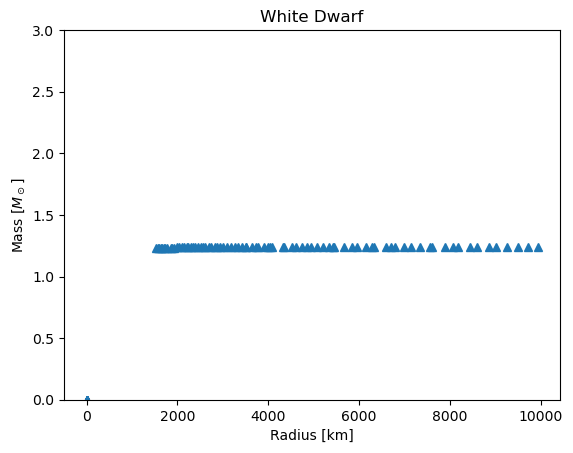

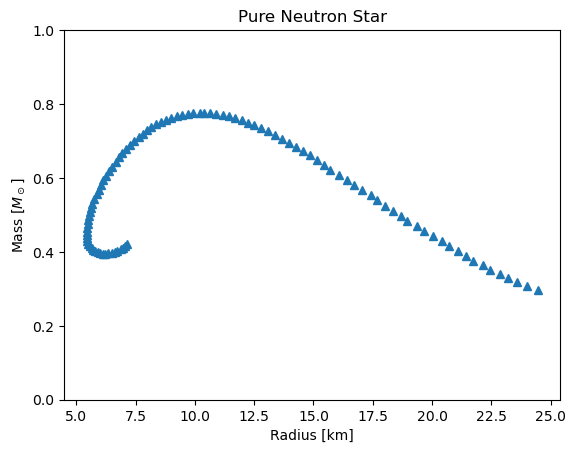

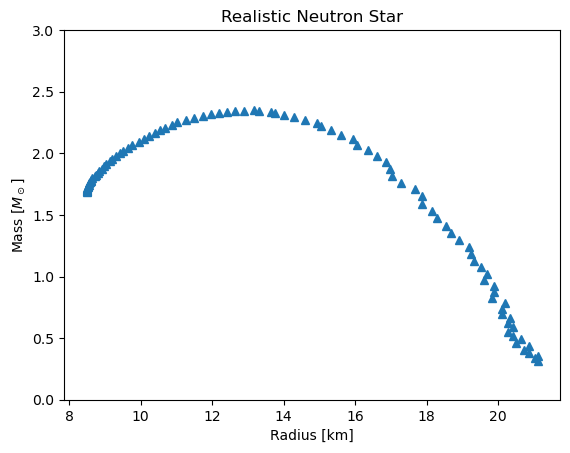

In [8]:
"""
Solves the TOV equations for three cases:

 1) WD: 
      white dwarf, modelled as a relativistic degenerate electron gas
"""
[Rs, Ms] = mass_radius(-16.0,-12.0,"WD")
plt.figure(3)
plt.ylim(0.0,3.0)
plt.plot(Rs,Ms,marker='^',linestyle="")
plt.title("White Dwarf")
plt.xlabel("Radius [km]")
plt.ylabel("Mass [$M_\odot$]")

plt.savefig('white_dwarf.pdf')

"""
 2) pureNS:
      pure neutron star, modelled as a noninteracting Fermi gas (neutrons) for "arbitrary" relativity
"""
[Rs, Ms] = mass_radius(-4.0,2.0,"pureNS")
plt.figure(2)
plt.plot(Rs,Ms,marker='^',linestyle="")
plt.title("Pure Neutron Star")
plt.ylim(0.0,1.0)
plt.xlabel("Radius [km]")
plt.ylabel("Mass [$M_\odot$]")

plt.savefig('pure_ns.pdf')

"""
 3) realisticNS: 
      realistic neutron star with simplified EoS that takes nuclear interactions into account
"""
[Rs, Ms] = mass_radius(-4.0,2.0,"realisticNS")
plt.figure(1)
plt.plot(Rs,Ms,marker='^',linestyle="")
plt.title("Realistic Neutron Star")
plt.ylim(0.0,3.0)
plt.xlabel("Radius [km]")
plt.ylabel("Mass [$M_\odot$]")

plt.savefig('relativistic_ns.pdf')